In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv('Walmart.csv')

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
Month,0
Year,0


In [ ]:
df.duplicated().sum()

np.int64(0)

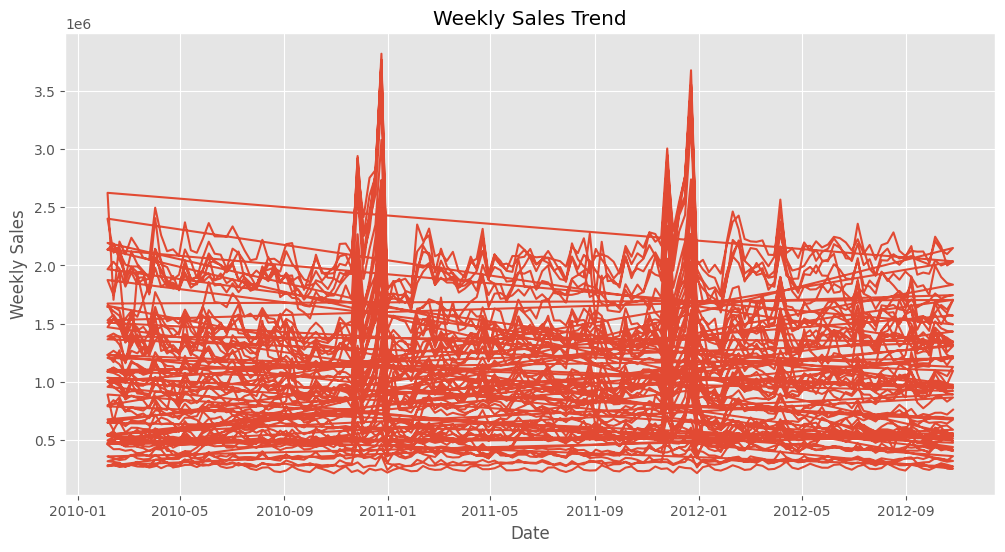

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Weekly_Sales'])
plt.title('Weekly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

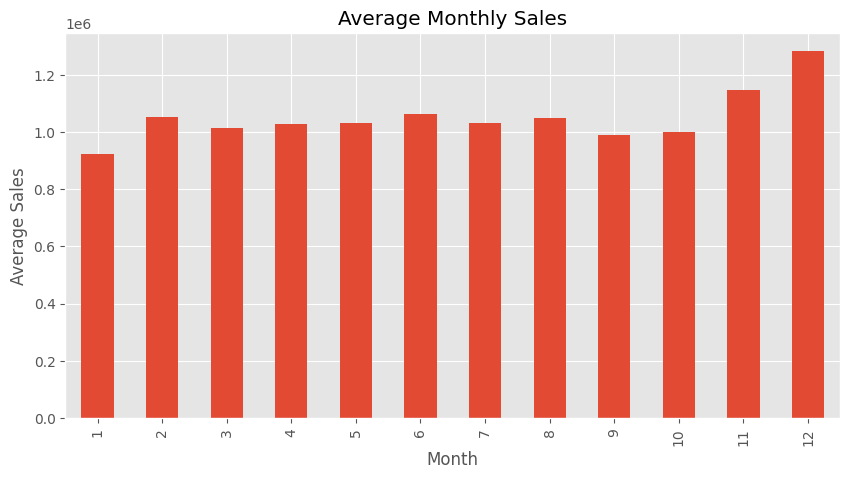

In [ ]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')

plt.title('Average Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Average Sales')

plt.show()

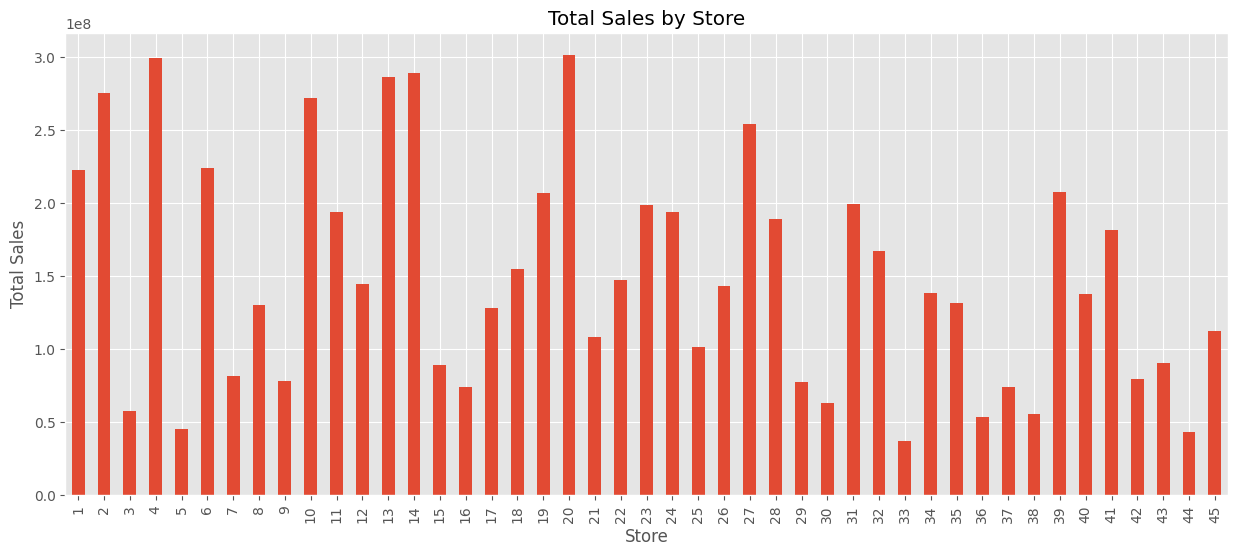

In [ ]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

plt.figure(figsize=(15,6))
store_sales.plot(kind='bar')

plt.title('Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Sales')

plt.show()

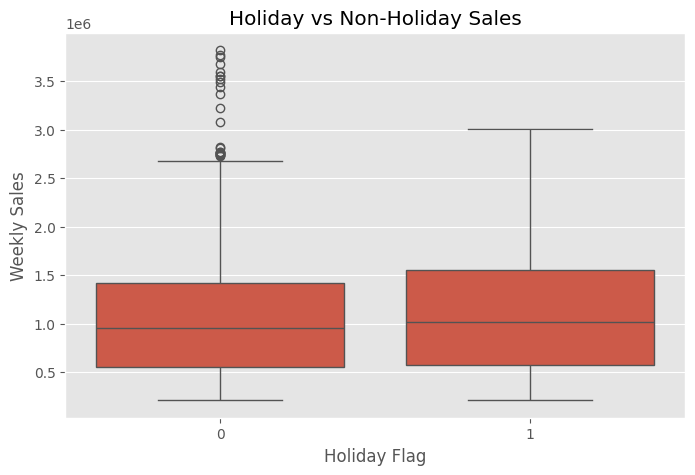

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Holiday_Flag',
    y='Weekly_Sales',
    data=df
)

plt.title('Holiday vs Non-Holiday Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Weekly Sales')

plt.show()

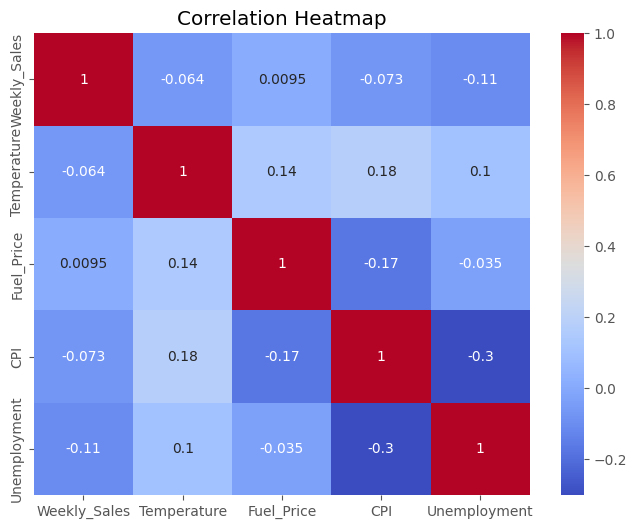

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Weekly_Sales',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

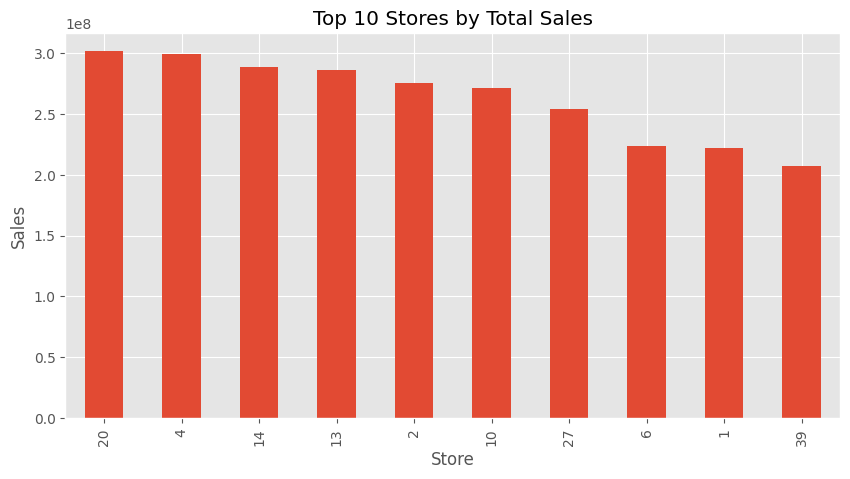

In [ ]:
top_stores = (
    df.groupby('Store')['Weekly_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

top_stores.plot(kind='bar')

plt.title('Top 10 Stores by Total Sales')
plt.xlabel('Store')
plt.ylabel('Sales')

plt.show()

In [ ]:
best_store = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

print(best_store.head())

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64


In [ ]:
best_month = df.groupby('Month')['Weekly_Sales'].mean().sort_values(ascending=False)

print(best_month)

Month
12    1.281864e+06
11    1.147266e+06
6     1.064325e+06
2     1.053200e+06
8     1.048017e+06
7     1.031748e+06
5     1.031714e+06
4     1.026762e+06
3     1.013309e+06
10    9.996321e+05
9     9.893353e+05
1     9.238846e+05
Name: Weekly_Sales, dtype: float64


In [ ]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06
